# Phân tích Khám phá (EDA) - Lớp Bronze
Notebook này nhằm mục đích kiểm tra chất lượng và trực quan hóa 3 nguồn dữ liệu thô (Bronze Layer) vừa lấy về:
1. Dữ liệu Giá cổ phiếu (`vn_stocks`)
2. Dữ liệu Báo cáo tài chính (`vn_financials`)
3. Dữ liệu Kinh tế vĩ mô (`world_bank`)


In [7]:
import pandas as pd
import json
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình giao diện biểu đồ xịn xò
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 6)

from deltalake import DeltaTable
import os

# Hàm đọc dữ liệu từ Bronze Layer (sử dụng siêu kiến trúc Delta Lake)
def load_bronze(source):
    # Tự động trỏ đúng đường dẫn
    current_dir = os.getcwd()
    base_path = ".." if current_dir.endswith("notebooks") else "."
        
    path = os.path.join(base_path, "data", "bronze", source)
    
    if not os.path.exists(path):
        print(f"❌ Không tìm thấy thư mục Delta: {path}")
        return pd.DataFrame()
    
    try:
        # Nhờ sức mạnh của Delta Lake, ta đọc toàn bộ lịch sử trong nháy mắt
        dt = DeltaTable(path)
        df = dt.to_pandas()
        
        # Xóa các dòng trùng lặp (nếu chạy run_bronze nhiều lần, giữ lại lần gần nhất)
        df = df.drop_duplicates(subset=[c for c in df.columns if c != '_ingested_at'], keep='last')
        print(f"✅ Đã load {len(df)} dòng từ {source} (Phiên bản {dt.version()})")
        return df
    except Exception as e:
        print(f"⚠️ Lỗi đọc Delta Table {source}: {e}")
        return pd.DataFrame()


# Load cả 3 bảng
df_market = load_bronze("vn_stocks")
df_fin = load_bronze("vn_financials")
df_macro = load_bronze("world_bank")




✅ Đã load 10819 dòng từ vn_stocks (Phiên bản 22)
✅ Đã load 54 dòng từ vn_financials (Phiên bản 10)
✅ Đã load 24 dòng từ world_bank (Phiên bản 17)


## 1. Dữ liệu Thị trường (`vn_stocks`)
Phân tích diễn biến giá đóng cửa (Close Price) và Khối lượng giao dịch (Volume) của các ngân hàng.
Mục tiêu: Đảm bảo chuỗi thời gian không bị đứt gãy.


In [8]:
df_market.columns

print(df_market["trade_date"].min(), df_market["trade_date"].max())
print(df_market["trade_date"].dt.year.value_counts().sort_index())


2017-08-09 2026-05-29


AttributeError: Can only use .dt accessor with datetimelike values

In [3]:
df_macro

,indicator_code,indicator_name,year,value,_ingested_at,_source
360,FP.CPI.TOTL.ZG,inflation_pct,2024,3.621093,2026-05-26T17:30:17.056283,world_bank
361,FP.CPI.TOTL.ZG,inflation_pct,2023,3.252893,2026-05-26T17:30:17.056283,world_bank
362,FP.CPI.TOTL.ZG,inflation_pct,2022,3.156507,2026-05-26T17:30:17.056283,world_bank
363,FP.CPI.TOTL.ZG,inflation_pct,2021,1.834716,2026-05-26T17:30:17.056283,world_bank
364,FP.CPI.TOTL.ZG,inflation_pct,2020,3.220934,2026-05-26T17:30:17.056283,world_bank
365,FP.CPI.TOTL.ZG,inflation_pct,2019,2.795824,2026-05-26T17:30:17.056283,world_bank
366,FP.CPI.TOTL.ZG,inflation_pct,2018,3.539628,2026-05-26T17:30:17.056283,world_bank
367,FP.CPI.TOTL.ZG,inflation_pct,2017,3.520257,2026-05-26T17:30:17.056283,world_bank
368,FR.INR.LEND,lending_rate_pct,2023,9.323000,2026-05-26T17:30:17.056283,world_bank
369,FR.INR.LEND,lending_rate_pct,2022,8.013333,2026-05-26T17:30:17.056283,world_bank


In [13]:
df_fin.tail

<bound method NDFrame.tail of     ticker   period  year  quarter       nim  npl_ratio     car  casa_ratio  \
15     VCB  2026-Q1  2026        1  0.670000   0.000000   9.320    0.000000   
16     VCB  2025-Q4  2025        4  0.660000   0.000000   9.720    0.000000   
17     VCB  2025-Q3  2025        3  0.650000   0.000000   9.640    0.000000   
18     BID  2026-Q1  2026        1  0.590000   0.000000   5.210    0.000000   
19     BID  2025-Q4  2025        4  0.500000   0.000000   5.460    0.000000   
20     BID  2025-Q3  2025        3  0.510000   0.000000   5.440    0.000000   
21     CTG  2026-Q1  2026        1  0.660000   0.000000   6.490    0.000000   
22     CTG  2025-Q4  2025        4  0.640000   0.000000   6.230    0.000000   
23     CTG  2025-Q3  2025        3  0.620000   0.000000   6.280    0.000000   
24     MBB  2026-Q1  2026        1  0.930000   0.000000   8.790    0.000000   
25     MBB  2025-Q4  2025        4  1.050000   0.000000  10.690    0.000000   
26     MBB  2025-Q3  2

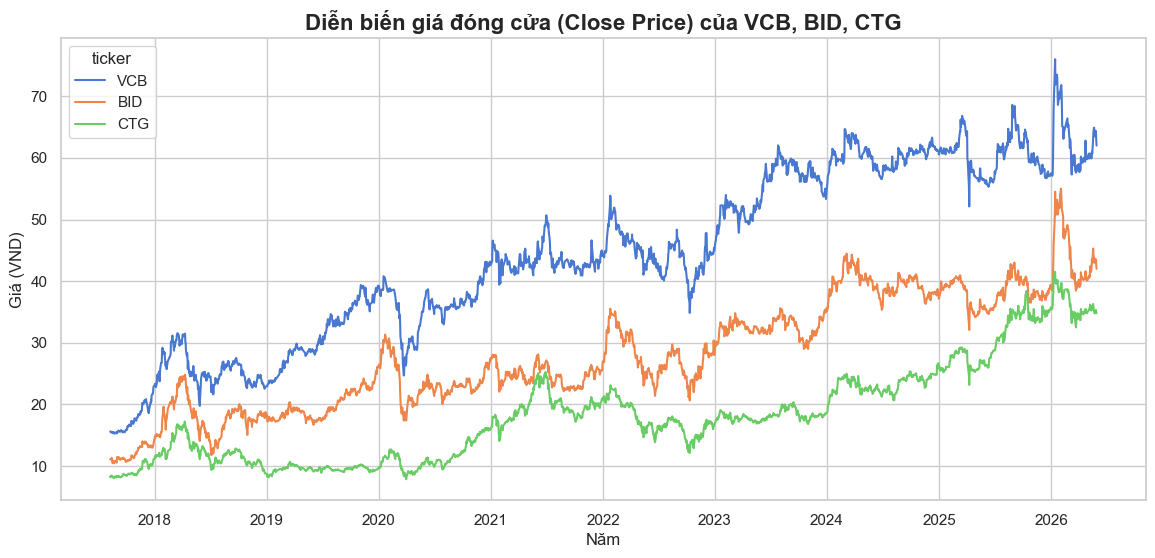

In [5]:
# Chuyển đổi trade_date sang datetime để vẽ trục X
df_market['trade_date'] = pd.to_datetime(df_market['trade_date'])

# Lọc 3 ngân hàng tiêu biểu
df_plot = df_market[df_market['ticker'].isin(['VCB', 'BID', 'CTG'])].copy()

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_plot, x='trade_date', y='close', hue='ticker')
plt.title("Diễn biến giá đóng cửa (Close Price) của VCB, BID, CTG", fontsize=16, fontweight='bold')
plt.ylabel("Giá (VND)")
plt.xlabel("Năm")
plt.show()


## 2. Dữ liệu BCTC (`vn_financials`)
Đây là trái tim của bài toán dự báo rủi ro ngân hàng. Chúng ta sẽ theo dõi 2 chỉ số sinh tử:
- **NPL (Nợ xấu):** Rủi ro tín dụng.
- **NIM (Biên lãi ròng):** Khả năng sinh lời từ lõi tín dụng.


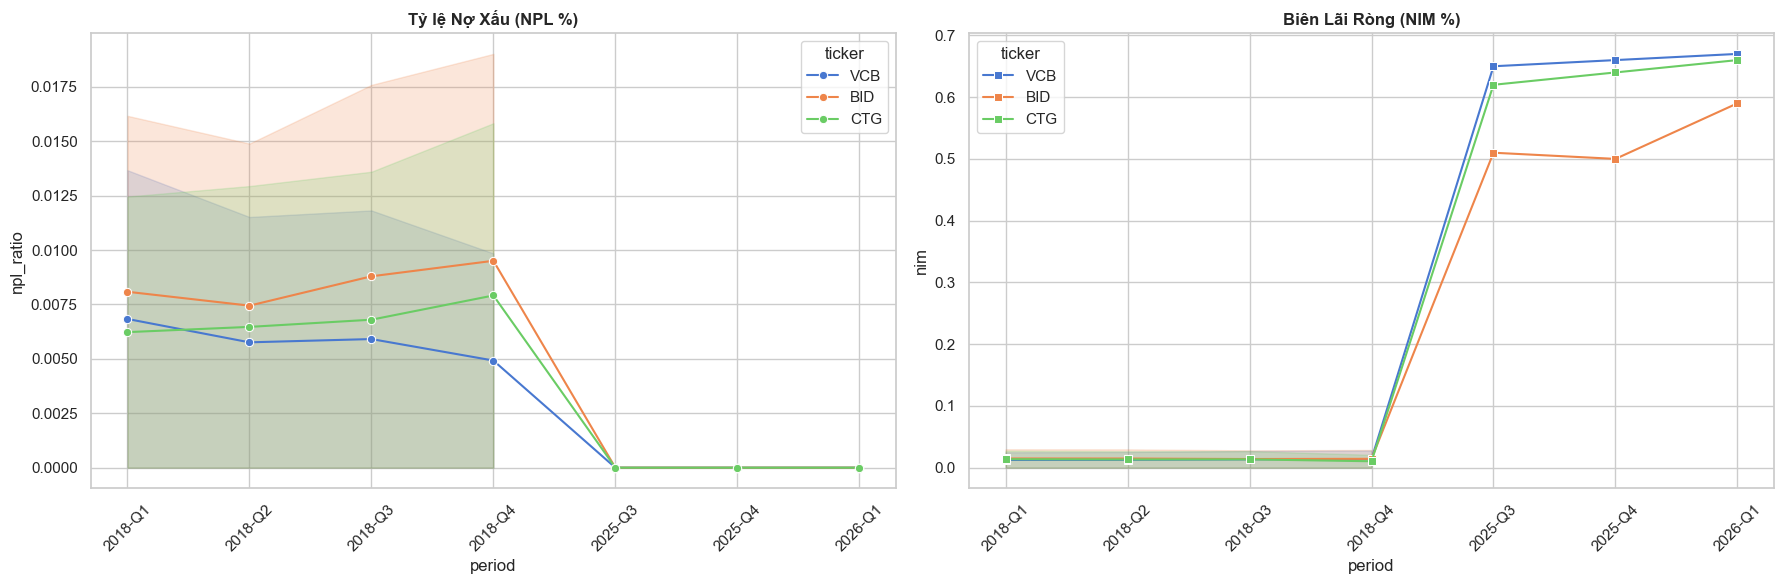

In [11]:
# Sắp xếp thời gian
df_fin_plot = df_fin[df_fin['ticker'].isin(['VCB', 'BID', 'CTG'])].copy()
df_fin_plot = df_fin_plot.sort_values(by=['year', 'quarter'])
df_fin_plot['period'] = df_fin_plot['year'].astype(str) + "-Q" + df_fin_plot['quarter'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Biểu đồ NPL
sns.lineplot(data=df_fin_plot, x='period', y='npl_ratio', hue='ticker', marker='o', ax=axes[0])
axes[0].set_title("Tỷ lệ Nợ Xấu (NPL %)", fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Biểu đồ NIM
sns.lineplot(data=df_fin_plot, x='period', y='nim', hue='ticker', marker='s', ax=axes[1])
axes[1].set_title("Biên Lãi Ròng (NIM %)", fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 3. Dữ liệu Vĩ mô (`world_bank`)
Phân tích Tăng trưởng GDP và Lạm phát của Việt Nam. Đây là các yếu tố môi trường ảnh hưởng gián tiếp đến khả năng trả nợ của khách hàng vay vốn.


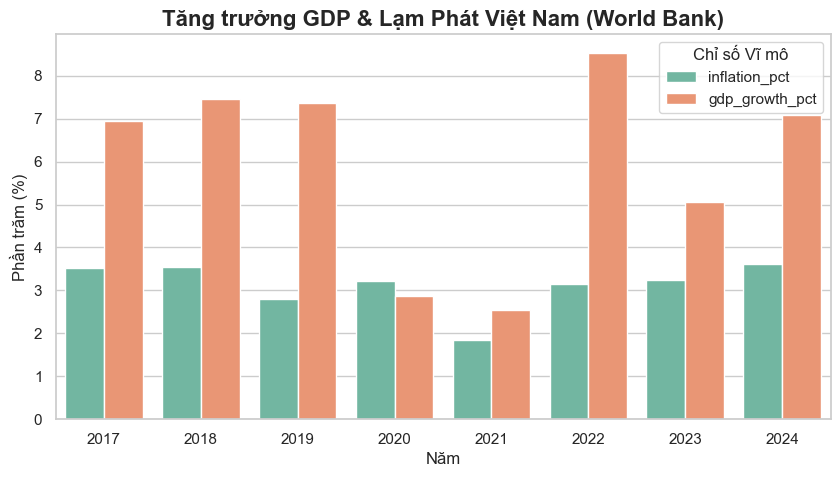

In [10]:
# Lọc Lạm phát (Inflation) và GDP Growth
df_macro_plot = df_macro[df_macro['indicator_name'].isin(['inflation_pct', 'gdp_growth_pct'])].sort_values('year')

plt.figure(figsize=(10, 5))
sns.barplot(data=df_macro_plot, x='year', y='value', hue='indicator_name', palette='Set2')
plt.title("Tăng trưởng GDP & Lạm Phát Việt Nam (World Bank)", fontsize=16, fontweight='bold')
plt.ylabel("Phần trăm (%)")
plt.xlabel("Năm")
plt.legend(title="Chỉ số Vĩ mô")
plt.show()


In [9]:
import pandas as pd
from IPython.display import display, Markdown

paths = {
    "gold_full": "../data/gold/gold_full.parquet",
    "gold_fallback": "../data/gold/gold_fallback.parquet",
    "gold_latest_snapshot": "../data/gold/gold_latest_snapshot.parquet",
}

for name, p in paths.items():
    display(Markdown(f"## {name}"))
    display(Markdown(f"`{p}`"))

    df = pd.read_parquet(p)

    print("shape:", df.shape)
    print("n_columns:", len(df.columns))
    display(Markdown("### Columns"))
    display(pd.DataFrame({"column": df.columns}))

    display(Markdown("### Dtypes"))
    display(df.dtypes.rename("dtype").to_frame())

    display(Markdown("### Missing (%) - Top 20"))
    miss = (df.isna().mean() * 100).sort_values(ascending=False).head(20)
    display(miss.rename("missing_pct").to_frame())

    if "trade_date" in df.columns:
        d = pd.to_datetime(df["trade_date"], errors="coerce")
        display(Markdown("### Date Range"))
        print("trade_date min:", d.min())
        print("trade_date max:", d.max())

    if "ticker" in df.columns:
        display(Markdown("### Ticker Stats"))
        print("n_tickers:", df["ticker"].nunique())
        display(df["ticker"].value_counts().head(10).rename("rows").to_frame())

    display(Markdown("### Sample Rows"))
    display(df.head(5))
    print("-" * 100)

## gold_full

`../data/gold/gold_full.parquet`

shape: (2084, 27)
n_columns: 27


### Columns

,column
0,trade_date
1,ticker
2,bank_name
3,year
4,quarter
5,month
6,open
7,high
8,low
9,close


...

n_tickers: 5


,rows
ticker,
BID,1
CTG,1
MBB,1
TCB,1
VCB,1


### Sample Rows

,trade_date,ticker,bank_name,year,quarter,month,open,high,low,close,...,casa_ratio,roe,roa,gdp_growth_pct,inflation_pct,lending_rate_pct,ret_1d,ret_5d,volatility_20d,volume_chg_5d
0,2026-05-29,BID,BIDV,2026,2,5,42.45,42.55,41.80,42.00,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.011765,-0.023256,0.020600,-0.062476
1,2026-05-29,CTG,VietinBank,2026,2,5,34.90,35.00,34.70,34.80,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.001435,0.000000,0.010404,-0.046084
2,2026-05-29,MBB,MB Bank,2026,2,5,25.00,25.20,24.85,25.00,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.014199,0.010190,-0.454977
3,2026-05-29,TCB,Techcombank,2026,2,5,32.65,33.05,32.65,32.75,...,NaN,NaN,NaN,NaN,NaN,NaN,0.004601,0.017081,0.012437,-0.040125
4,2026-05-29,VCB,Vietcombank,2026,2,5,63.00,63.00,61.80,62.00,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.012739,-0.023622,0.014799,-0.283110


----------------------------------------------------------------------------------------------------


Epoch 1 Loss: 0.3674308657646179
Epoch 2 Loss: 0.3666938841342926
Epoch 3 Loss: 0.3654114902019501
Epoch 4 Loss: 0.3637412488460541
Epoch 5 Loss: 0.3618326485157013
Epoch 6 Loss: 0.3598368167877197
Epoch 7 Loss: 0.35788694024086
Epoch 8 Loss: 0.35607460141181946
Epoch 9 Loss: 0.35441848635673523
Epoch 10 Loss: 0.35277533531188965
Epoch 11 Loss: 0.35051220655441284
Epoch 12 Loss: 0.3459751605987549
Epoch 13 Loss: 0.33780646324157715
Epoch 14 Loss: 0.3267793357372284
Epoch 15 Loss: 0.3187728524208069
Epoch 16 Loss: 0.31866610050201416
Epoch 17 Loss: 0.31628042459487915
Epoch 18 Loss: 0.3161410391330719
Epoch 19 Loss: 0.31559985876083374
Epoch 20 Loss: 0.31526678800582886
Epoch 21 Loss: 0.31491073966026306
Epoch 22 Loss: 0.3144027292728424
Epoch 23 Loss: 0.3141396641731262
Epoch 24 Loss: 0.3139563202857971
Epoch 25 Loss: 0.3138352036476135
Epoch 26 Loss: 0.3137035667896271
Epoch 27 Loss: 0.31356939673423767
Epoch 28 Loss: 0.3134517967700958
Epoch 29 Loss: 0.3133494555950165
Epoch 30 Loss:

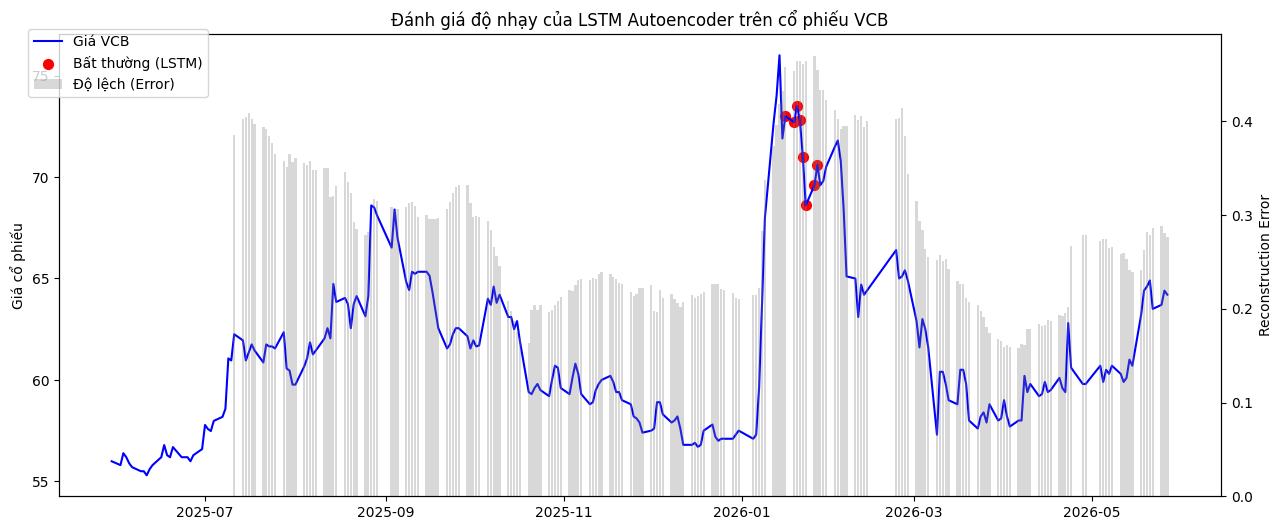

In [1]:
import sys
import os
import matplotlib.pyplot as plt

# Trỏ đường dẫn ra thư mục gốc để import code của Finsight
sys.path.append(os.path.abspath('..'))

from ml.feature_store import build_anomaly_features
from ml.anomaly.lstm_autoencoder import LSTMAnomalyDetector

# 1. Kéo dữ liệu
df = build_anomaly_features(days=365)

# 2. Huấn luyện mô hình ngay trong Notebook (Với 50 Epochs như bạn cài đặt)
detector = LSTMAnomalyDetector(seq_length=30, epochs=50)
res_vcb = detector.fit_predict(df, 'VCB')

# 3. Vẽ biểu đồ
fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.plot(res_vcb['trade_date'], res_vcb['close_price'], color='blue', label='Giá VCB')
ax1.set_ylabel('Giá cổ phiếu')

anomalies = res_vcb[res_vcb['is_anomaly_lstm'] == True]
ax1.scatter(anomalies['trade_date'], anomalies['close_price'], color='red', s=50, label='Bất thường (LSTM)')

ax2 = ax1.twinx()
ax2.bar(res_vcb['trade_date'], res_vcb['reconstruction_error'], color='gray', alpha=0.3, label='Độ lệch (Error)')
ax2.set_ylabel('Reconstruction Error')

plt.title('Đánh giá độ nhạy của LSTM Autoencoder trên cổ phiếu VCB')
fig.legend(loc="upper left", bbox_to_anchor=(0.1,0.9))
plt.show()
